# Homework 7 Template

Rixin Li & G . Besla



In [ ]:
 # Make edits where instructed - look for "****", which indicates where you need to add code. 

In [45]:
# import necessary modules
# numpy provides powerful multi-dimensional arrays to hold and manipulate data
import numpy as np
# matplotlib provides powerful functions for plotting figures
import matplotlib.pyplot as plt
import matplotlib 
# astropy provides unit system and constants for astronomical calculations
import astropy.units as u
import astropy.constants as const
# import Latex module so we can display the results with symbols
from IPython.display import Latex
%matplotlib inline
# import CenterOfMass to determine the COM pos/vel of M33
from CenterOfMass import CenterOfMass # this is to import the function from the homework
# import the GalaxyMass to determine the mass of M31 for each component
from GalaxyMass import ComponentMass
from ReadFile import Read
 # this is so we can read the file and take the data for our calculations

# M33AnalyticOrbit

In [129]:
class M33AnalyticOrbit:
    """ class to compute/integrate the acceleration of M33 around M31 and obtain its position/velocity in time """
    
    def __init__(self, filename):
        ''' Class to Calculate the analytical orbit of M33 around M31
            
            PARAMETERS
            self: allows all information to be store and produce its own data
            filename: `str` is the file the data will come from to make the calculations
            
        '''
        # relative position/velocity of M33 to M31
        #  get the gravitational constant (the value is 4.498502151575286e-06)
        self.G = const.G.to(u.kpc**3/u.Msun/u.Gyr**2).value #gravity
    
        #  store the output file name
        self.filename = filename # filename
        # get the current pos/vel of M33 
        # create an instance of the  CenterOfMass class for M33 
        COM33 = CenterOfMass('M33_000.txt',2) # define the com for m33 disk particles
        #  store the position VECTOR of the M33 COM (.value to get rid of units)
        COMPM33 = COM33.COM_P(0.1).value # position
        #   store the velocity VECTOR of the M33 COM (.value to get rid of units)
        COMVM33 = COM33.COM_V(COMPM33[0]*u.kpc, COMPM33[1]*u.kpc, COMPM33[2]*u.kpc).value #velocity
        # get the current pos/vel of M31 
        #   create an instance of the  CenterOfMass class for M31 
        COM31 = CenterOfMass('M31_000.txt',2) # define the com for m31 disk particles
        # **** store the position VECTOR of the M31 COM (.value to get rid of units)
        COMPM31 = COM31.COM_P(0.1).value # position
        # **** store the velocity VECTOR of the M31 COM (.value to get rid of units)
        COMVM31 = COM31.COM_V(COMPM31[0]*u.kpc, COMPM31[1]*u.kpc, COMPM31[2]*u.kpc).value #velocity
        # the scale lengths/masses of each component in m31
        ### store the DIFFERENCE between the vectors posM33 - posM31
        # create two VECTORs self.r0 and self.v0 and have them be the relative position and velocity VECTORS of M33
        self.r0 = (COMPM33 - COMPM31)  # difference of position
        self.v0 = (COMVM33- COMVM31)  # difference of velocity
        #  get the mass of each component in M31 
        #  self.rdisk = scale length (no units)
        self.rdisk = 5 # disk radius
        #  self.Mdisk set with ComponentMass function. Remember to *1e12 to get the right units. Use the right ptype
        self.Mdisk = (ComponentMass("M31_000.txt",2)) * 1e12 # disk mass
        # self.rbulge = set scale length (no units)
        self.rbulge = 1 # bulge radius
        # **** self.Mbulge  set with ComponentMass function. Remember to *1e12 to get the right units Use the right ptype
        self.Mbulge = (ComponentMass("M31_000.txt",3)) * 1e12 # bulge mass
        #  self.rhalo = set scale length from HW5 (no units)
        self.rhalo = 62 # halo radius taken from solutions on Hw5
        # **** self.Mhalo set with ComponentMass function. Remember to *1e12 to get the right units. Use the right ptype
        self.Mhalo = (ComponentMass("M31_000.txt",1)) * 1e12 # halo mass 
    # acceleration terms that will compute the gravitational acceleration vectors from the 3 types of particles in the M31 galaxy
    def HernquistAccel(self,M,r_a,r): # it is easiest if you take as an input the position VECTOR 
        ''' Function used for both the halo/bulge acceleration 
            
            PARAMETERS
            self: allows all information to be store and produce its own data
            M: is the total halo/ bulge mass components
            r_a: is scale length and rmag is the magnitude of the relative position vector
            r: is the corresponding vector for rmag (x,y,z)

            Returns: Hern : the acceleration vector from a hernquist potential
        '''
        ### **** Store the magnitude of the position vector
        rmag = np.linalg.norm(r) #the magnitude taken from hernquist profile
        
        ### *** Store the Acceleration
        Hern = (-self.G*M)/(rmag *(r_a + rmag)**2) * r # the equation for acceleration
        # NOTE: we want an acceleration VECTOR so you need to make sure that in the Hernquist equation you 
        # use  -G*M/(rmag *(ra + rmag)**2) * r --> where the last r is a VECTOR 
        return Hern # return the final calculation with both components 
    
    
    
    def MiyamotoNagaiAccel(self,M,r_d,r):# it is easiest if you take as an input a position VECTOR  r 
        ''' Function used to compute the acceleration for a M31 disk using an approximation called Miyamoto-Nagai 1975 profile    
            
            PARAMETERS
            self: allows all information to be store and produce its own data
            M: is the total disk mass components
            r_d: is self.rdisk and zd is the self.rdisk/5, the radius of the disk part kpc
            r: is the corresponding vector  (x,y,z)

            Returns: MNP: the acceleration vector from a Miyamoto-Nagai profile.
        '''
        ### Acceleration **** follow the formula in the HW instructions
        R = np.sqrt(r[0]**2+r[1]**2) # x and y components for r
        zd= r_d/5 # the disk scale height
        B = r_d + np.sqrt(r[2]**2+zd**2) # using the z radial component using the r vector
        #  the z component is different than in the x or y directions. 
        zs = np.array([ 1, 1, (B/np.sqrt((r[2]**2) + (zd**2)))]) # differences in the z direction
        #  multiplying the whole thing by an extra array that accounts for the differences in the z direction:
        MNP = ((-self.G * M)/(R**2+B**2)**1.5)*r*(zs) # equation including all components into one 
        return MNP # returns the final calculation of the acceleration using the components
 
    def M31Accel(self, r): # input should include the position vector, r
        ''' Function that computes all acceleration vectors from each galaxy component such as disk, bulge, halo, hernquist and Miyamoto-Nagai profile.   
            
            PARAMETERS
            self: allows all information to be store and produce its own data
            r: 3d position of the galaxy m31 (x,y,z)

            Returns: M31A:  3D vector of the total acceleration
        '''

        ### Call the previous functions for the halo, bulge and disk
        halo = self.HernquistAccel(self.Mhalo,self.rhalo, r) # the halo component
        bulge = self.HernquistAccel(self.Mbulge,self.rbulge, r) # the bulge component
        disk = self.MiyamotoNagaiAccel(self.Mdisk,self.rdisk, r) # the disk component
        # **** these functions will take as inputs variable we defined in the initialization of the class like 
        # self.rdisk etc. 
        M31A = halo + bulge + disk   # equation for the sum 
            # return the SUM of the output of the acceleration functions - this will return a VECTOR 
        return M31A # the total calculation of the m21 aceleration using all components 
    
    def LeapFrog(self,dt,r,v): # take as input r and v, which are VECTORS. Assume it is ONE vector at a time
        ''' Function to solve the orbit of M33 by using the leapfrog integration method (forward/backward). updates the positions and velocities using standard kinematic equations   
            forward only calculating future orbits-positive
            PARAMETERS
            self: allows all information to be store and produce its own data
            dt: time interval for integration 
            r: starting position vector for the M33 com position relative to M31
            v: starting velocity vector  for the M33 relative to M31
            Returns: rnew and vnew:  equation for n+1 timesteps using the previous equation 
        '''
        # predict the position at the next half timestep
        rhalf = r+(v*(dt/2)) # 3d position vector at the  middle of the timestep using com position/veocity
        # predict the final velocity at the next timestep using the acceleration field at the rhalf position 
        vnew = v+(self.M31Accel(rhalf)*dt) # velocity is moved a full time step using the acceleration at 1/2 timestep
        # predict the final position using the average of the current velocity and the final velocity
        # this accounts for the fact that we don't know how the speed changes from the current timestep to the next,  approximate it using the average expected speed over the time interval dt. 
        rnew = rhalf + (vnew*(dt/2)) # position vector moved to full time step using the average velocity during the time step
        return rnew, vnew # new position and velcoity vectors
     
    def OrbitIntegration(self, t0, dt, tmax):
        ''' Function to loop over the leapfrog integrator and compute the motion equations, future orbit of M33 for 10 gyr into the future
                
            PARAMETERS
            self: allows all information to be store and produce its own data
            t0: the starting point for time integration 
            dt: time interval for integration
            tmax: the ending point for time integration to stop in the while loop 
            Returns: stores the array into a txt file after filename
         '''
        # initialize the time to the input starting time
        t = t0 # the starting point 
        # initialize an empty array of size :  rows int(tmax/dt)+2  , columns 7
        orbit = np.zeros((int(tmax/dt)+2,7) ) # storing the results in an array to initialize  
        # initialize the first row of the orbit
        orbit[0] = t0, *tuple(self.r0), *tuple(self.v0)
        # this above is equivalent to - orbit[0] = t0, self.r0[0], self.r0[1], self.r0[2], self.v0[0], self.v0[1], self.v0[2]
          # initialize a counter for the orbit.  
        i = 1 # since we already set the 0th values, we start the counter at 1
        pos,vel = self.r0,self.v0 # storing the initial position and velocties before   the loop starts
        # start the integration (advancing in time steps and computing LeapFrog at each step)
        while (t<tmax):  # as long as t has not exceeded the maximal time- tmax 
            #  advance the time by one timestep, dt
            t = t+dt # added to the time by one step
            #  store the new time in the first column of the ith row
            orbit[i ] = t, *tuple(pos), *tuple(vel) # the time will be on the first column
            #  advance the position and velocity using the LeapFrog scheme, LeapFrog returns a position vector and a velocity vector  
            pos,vel = self.LeapFrog(dt,pos,vel )  # implement the leapfrog integration for position and velocity 
            # ****  store the new position vector into the columns with indexes 1,2,3 of the ith row of orbit,  where the syntax is row n, start at column 5 and end BEFORE column 8
            #orbit[i,1:4] = pos # will display the results for position in colums 3-5             
            #  store the new position vector into the columns with indexes 1,2,3 of the ith row of orbit
            #orbit[i,4:7] = vel # stores the results in 6-8
            #  update counter i , where i is keeping track of the number of rows (i.e. the number of time steps)
            i=i+1 # tracks rows and adds by one
         
        # write the data to a file
        np.savetxt(self.filename, orbit, fmt = "%11.3f"*7, comments='#', 
                   header="{:>10s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}"\
                   .format('t', 'x', 'y', 'z', 'vx', 'vy', 'vz')) # storing the file
        
        # there is no return function
        
        

In [130]:
# plot for predicted M33 orbit from t0=0 gyr to tmax=10gyr dt=0.5 gyr but first make file
M33 = M33AnalyticOrbit('M33Orbit.txt')
M33.OrbitIntegration( 0, 0.1, 10)
 

In [131]:
# obtain data from file 
# headers:  t, x, y, z, vx, vy, vz 
# first lets name the files for each galaxy
filename1 = "Orbit_MW.txt"
filename2 = "Orbit_M31.txt"
filename3 = "Orbit_M33.txt"
filename4 = "M33Orbit.txt"
# then make it read the data files of the orbit of each galaxy
data1 = np.genfromtxt(filename1, comments= '#', names= True)
data2 = np.genfromtxt(filename2, comments= '#', names= True)
data3 = np.genfromtxt(filename3, comments= '#', names= True)
data4 = np.genfromtxt(filename4, comments= '#', names= True)
# now we can get the data
#time
time1 = data1['t']
time2 = data2['t']
time3 = data3['t']
time4 = data4['t']
# postion
pos1 = (data1['x'],data1['y'],data1['z'])
pos2 = (data2['x'],data2['y'],data2['z'])
pos3 = (data3['x'],data3['y'],data3['z'])
pos4 = (data4['x'],data4['y'],data4['z'])
# velocity
vel1 = (data1['vx'],data1['vy'],data1['vz'])
vel2 = (data2['vx'],data2['vy'],data2['vz'])
vel3 = (data3['vx'],data3['vy'],data3['vz'])
vel4 = (data4['vx'],data4['vy'],data4['vz'])

In [132]:
# function to compute the magnitude of the difference between two vectors, returns both the relative position and relative velocity for two  
def MagDiff(G1,G2):
    """Function that computes the difference between two vectors which in this is two galaxies. used for both velocity and position
        x1: is the first galaxy which we compute its magnitude of pos/vel
        x2: the second galaxy 
    outputs: Sep: the magnitude of the relative seperation and the velocity
    """
    x1,y1,z1 = G1 # this is the first galaxy which will take the x,y,z positions/velocity
    x2,y2,z2 = G2 # this is the 2nd galaxy which will take the x,y,z positions/velocity
    minl = min(len(x1),len(x2)) # error due to length so ensure they are the same length
    x1,y1,z1 = x1[:minl],y1[:minl],z1[:minl] # arrays the same length for both galaxies
    x2,y2,z2 = x2[:minl],y2[:minl],z2[:minl] 
    xnew = x2 - x1 # taking the difference of each galaxies position/velocity before we take the magnitude of it all
    ynew = y2 - y1
    znew = z2 - z1
    sep = np.sqrt((xnew**2) + (ynew**2) + (znew**2)) # now we take the square root of it all
    return sep # this is the magnitude of the difference between two vectors

In [133]:
# Determine the magnitude of the relative position and velocities  
# of M33 and M31 old
RelPosM33M31 = MagDiff(pos3,pos2)
VelM33M31 = MagDiff(vel3,vel2)
#  M33AnalyticOrbit and m31
PosM33  = MagDiff(pos4,pos2)
VelM33 = MagDiff(vel4,vel2)

In [134]:
# ensure the time is also the same length
mint = min(len(time2),len(VelM33)) # error due to length so ensure they are the same length
newt  = time2[:mint]  # arrays the same length for the time
mint2 = min(len(time2),len(PosM33)) # error due to length so ensure they are the same length
newt2  = time2[:mint2]  # arrays the same length for the time     

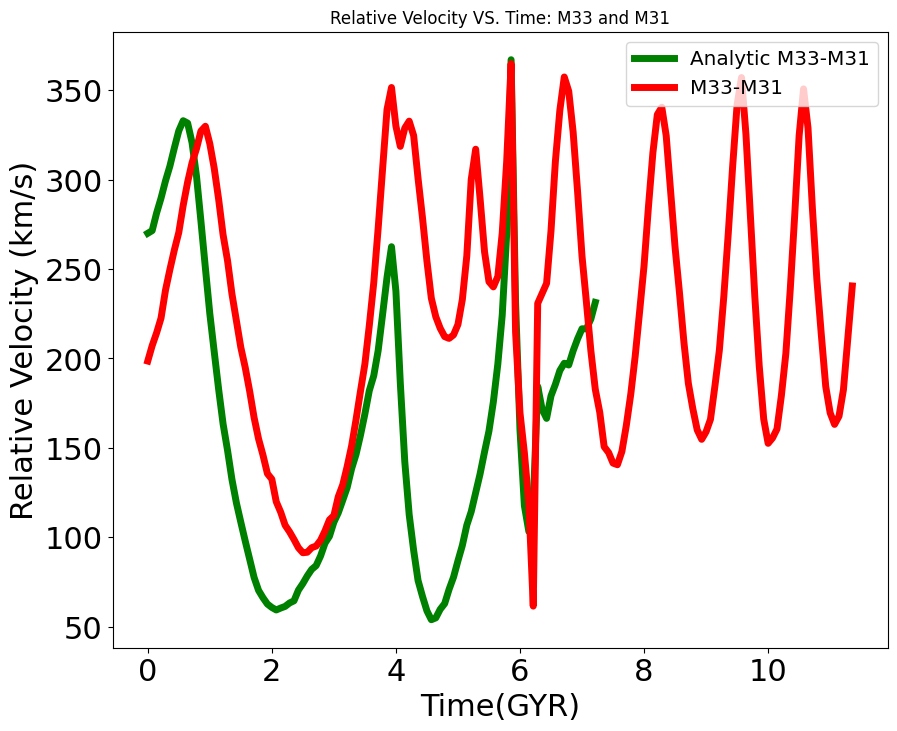

In [137]:
# Plot the Orbit of M33AnalyticOrbit and M31 and overplot from last homework  
 
fig,ax = plt.subplots(figsize=(10,8))

#adjust tick label font size
label_size = 22
matplotlib.rcParams['xtick.labelsize'] = label_size 
matplotlib.rcParams['ytick.labelsize'] = label_size
#plot magnitude of relative velocity vs time for M33 and M31
plt.plot(newt, VelM33  ,color = "green", linewidth = 5, label='Analytic M33-M31')
plt.plot(time2, VelM33M31 ,color = "red", linewidth = 5, label='M33-M31')
# Axes labels 
plt.xlabel('Time(GYR)',fontsize=22) 
plt.ylabel('Relative Velocity (km/s)', fontsize=22)
plt.title("Relative Velocity VS. Time: M33 and M31")
# Legeng
plt.legend(loc='upper right',fontsize='x-large')
plt.show()

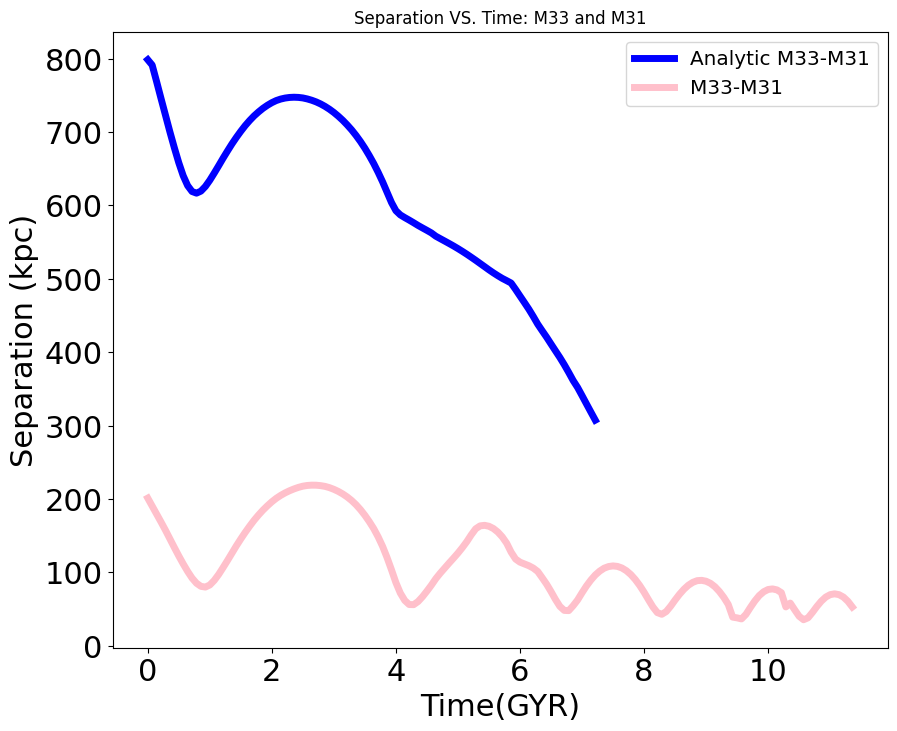

In [138]:
# Plot the position of M33AnalyticOrbit and M31 and overplot from last homework  
 
fig,ax = plt.subplots(figsize=(10,8))

#adjust tick label font size
label_size = 22
matplotlib.rcParams['xtick.labelsize'] = label_size 
matplotlib.rcParams['ytick.labelsize'] = label_size
#plot magnitude of relative velocity vs time for M33 and M31
plt.plot(newt2 , PosM33  ,color = "blue", linewidth = 5, label='Analytic M33-M31')
plt.plot(time2, RelPosM33M31 ,color = "pink", linewidth = 5, label='M33-M31')
# Axes labels 
plt.xlabel('Time(GYR)',fontsize=22) 
plt.ylabel('Separation (kpc)', fontsize=22)
plt.title("Separation VS. Time: M33 and M31")
# Legeng
plt.legend(loc='upper right',fontsize='x-large')
plt.show()

In [ ]:
#Part 2
#The plots are somewhat alike for the total velocity  but for the total position (separation)  
#  it  is off by a lot. I am not sure if I made an computational error in the beginning when initializing 
# position/velocity or it was expected. I checked the self.r0 and it was around 200 kpc which is the correct magnitude 
# for the separation of m33-m31. The plot for velocity matched up pretty well though, which displayed the analytic/simulation relation nicely. 
# It seems like the analytic one decays quicker than the original which is expected since there's no
# dynamical friction and/or mw influence. Solely m31 influences. At 7 gyr you can see the two  merge together nicely.

In [ ]:
#Part 3
# If we involved dynamical friction and the gravitational influence of the mw we would see the orbit
# speed up its process of decaying and essentially causing its overall orbit to become smaller. While also slowing down
#  over time. Since its obtainining the energy from m33. The mw's influence would pull both 
# galaxies causing their orbital paths to change over time. so by adding these physical components, we can achieve a more
#  improved/accurate  representation of the complex dynamics of galaxies interacting together. 

In [ ]:
#Part 4
# The inclusion of the milky way is cruicial for the overall accuracy of the analytic model. So  
# it essentially makes or breaks this model. The influence of the MW causes the orbit of M33 to be altered but  
# also the merging dynamics between M33/M31. You coud include its effects by adding the mw just as another mass object.  
# Then computing the relative position of it but also using its gravitational influence in the total acceleration function.
# Basically making it a 3 body problem which can be complex but doable with our functions.
# overalll, applying this methodology can improve and provide a better implication of the future orbit of M33/M31. 
